# Fine-Tuning

## 0. Mount Drive (only for Google Colab)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 1. Installation & Uninstallation (only for Google Colab)

In [ ]:
# install Unsloth and dependencies
%%capture
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes

In [ ]:
# uninstall Sentence-Transformers
!pip uninstall sentence-transformers

In [ ]:
# delete automatically installed Torchvision
!rm -rf /usr/local/lib/python3.12/dist-packages/torchvision
!rm -rf /usr/local/lib/python3.12/dist-packages/torchvision-*.dist-info

In [ ]:
# reinstall Torchvision
!pip install --force-reinstall torchvision --index-url https://download.pytorch.org/whl/cu128

## 2. Initialization

In [ ]:
import os
import sys

os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [ ]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

In [ ]:
%%capture
import os
os.environ["UNSLOTH_VLLM_STANDBY"] = "1" # [NEW] Extra 30% context lengths!
if "COLAB_" not in "".join(os.environ.keys()):
    # If you're not in Colab, just use pip install or uv pip install
    !pip install unsloth vllm
else:
    pass # For Colab / Kaggle, we need extra instructions hidden below \/

In [ ]:
%%capture
import os
!pip install --upgrade -qqq uv
if "COLAB_" not in "".join(os.environ.keys()):
    # If you're not in Colab, just use pip install!
    !pip install unsloth vllm
else:
    try: import numpy, PIL; _numpy = f'numpy=={numpy.__version__}'; _pil = f'pillow=={PIL.__version__}'
    except: _numpy = "numpy"; _pil = "pillow"
    try: import subprocess; is_t4 = "Tesla T4" in str(subprocess.check_output(["nvidia-smi"]))
    except: is_t4 = False
    _vllm, _triton = ('vllm==0.9.2', 'triton==3.2.0') if is_t4 else ('vllm==0.15.1', 'triton')
    !uv pip install -qqq --upgrade {_vllm} {_numpy} {_pil} torchvision bitsandbytes xformers unsloth
    !uv pip install -qqq {_triton}
    !uv pip install -qqq --no-deps --upgrade "torchao>=0.16.0"
!uv pip install transformers==4.56.2
!uv pip install --no-deps trl==0.22.2

## 3. Unsloth

In [ ]:
# for zero-shot
from unsloth import FastLanguageModel, is_bfloat16_supported
import torch
max_seq_length = 4192 # Can increase for longer reasoning traces
lora_rank = 16 # Larger rank = smarter, but slower

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Llama-3.2-3B-Instruct-bnb-4bit",
    max_seq_length = max_seq_length,
    load_in_4bit = True, # False for LoRA 16bit
    fast_inference = False, # Enable vllm fast inference
    max_lora_rank = lora_rank
)

model = FastLanguageModel.get_peft_model(
    model,
    r = lora_rank, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj"
    ], # Remove QKVO if out of memory
    lora_alpha = lora_rank,
    use_gradient_checkpointing = "unsloth", # Enable long context finetuning
    random_state = 3407,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.5: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.5.5 patched 28 layers with 28 QKV layers, 28 O layers and 0 MLP layers.


In [ ]:
from unsloth import FastLanguageModel, is_bfloat16_supported
import torch
max_seq_length = 5800 # Can increase for longer reasoning traces
lora_rank = 16 # Larger rank = smarter, but slower

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Llama-3.2-1B-Instruct-bnb-4bit",
    max_seq_length = max_seq_length,
    load_in_4bit = True, # False for LoRA 16bit
    fast_inference = False,
    max_lora_rank = lora_rank
)

model = FastLanguageModel.get_peft_model(
    model,
    r = lora_rank, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj"
    ],
    lora_alpha = lora_rank,
    use_gradient_checkpointing = "unsloth", # Enable long context finetuning
    random_state = 3407,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.03G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.5.2 patched 16 layers with 16 QKV layers, 16 O layers and 0 MLP layers.


## 4. Data Preparation

In [ ]:
# prompt
import json
import pandas as pd
from datasets import Dataset

instruction = """
Kamu adalah asisten yang ahli dalam pembentukan Graf Pengetahuan (Knowledge Graph). Tugasmu adalah mengonversi teks secara langsung menjadi representasi Resource Description Framework (RDF) secara akurat, eksplisit, dan terstruktur.

Instruksi:
- Buat triplet relasi utama antar entitas yang ditemukan dalam teks.
- Gunakan prefix kosong : (http://example.org/) untuk entitas buatan, serta gunakan prefix standar rdf:, rdfs:, dan xsd:.
- Ubah spasi pada nama entitas dan relasi menjadi format Snake_Case dengan awalan huruf kapital.
- Langsung hasilkan code block sintaks Turtle (.ttl) tanpa penjelasan atau kata pembuka apa pun.

Sajikan jawaban dengan format persis seperti berikut:
@prefix : <http://example.org/> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

# Triples
:Node_Utama :memilikiRelasi :Elemen_A .
:Elemen_A :berelasiDengan :Entitas_Lain .
...

# Definisi Node
:Node_Utama rdf:type :Topik_Utama ;
    rdfs:label "Deskripsi atau nilai dari node utama." .

:Elemen_A rdf:type :Kategori_Elemen ;
    rdfs:label "Deskripsi elemen tersebut." .
...
"""

# if zero-shot, comment the following instruction
additional_instruction = {
    "abstrak": """
---

Sebagai panduan, berikut 1 buah contoh teks beserta format serta hasil RDF dan analisis teks yang diharapkan:

CONTOH JUDUL TEKS: Pengaruh Iklim Sekolah dan Pemantauan Orang Tua terhadap Perilaku Perundungan Pelajar

CONTOH ISI TEKS:
Perilaku perundungan di sekolah masih menjadi persoalan serius di Indonesia. Penelitian untuk memperoleh faktor-faktor yang dapat mengurangi perilaku perundungan pelajar perlu dilakukan sebagai dasar untuk merancang program intervensi. Penelitian ini bertujuan untuk mendapatkan gambaran perundungan yang terjadi pada pelajar sekolah dan kemudian menguji pengaruh iklim sekolah dan pemantauan orang tua terhadap perilaku perundungan. Penelitian ini menggunakan metode penelitian kuantitatif. Data yang digunakan adalah data primer dengan menyebarkan kuesioner kepada para pelajar sekolah. Analisis data dilakukan dengan menerapkan regresi logistik. Hasil penelitian memperlihatkan bahwa jenis perundungan yang menonjol dijumpai adalah perundungan verbal dan relasional. Dengan menerapkan analisis regresi logistik, hasil penelitian menunjukkan bahwa iklim sekolah yang positif menurunkan kemungkinan para pelajar untuk menjadi korban perundungan. Selain itu, iklim sekolah yang positif dan pemantauan orang tua mengurangi kemungkinan pelajar untuk menjadi pelaku perundungan. Pendidikan karakter merupakan salah satu upaya sekolah untuk mencegah terjadinya perundungan di sekolah. Dengan demikian, baik pihak sekolah maupun orang tua berperan dalam mengurangi maraknya perilaku perundungan di kalangan remaja pelajar.

CONTOH HASIL RDF TEKS:
@prefix : <http://example.org/> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

# Triples
:Penelitian :memilikiMasalah :Masalah_Penelitian .
:Penelitian :bertopik :Topik_Penelitian .
:Penelitian :berjudul :Judul_Penelitian .
:Penelitian :menggunakanMetodologi :Metodologi_Penelitian .
:Penelitian :menggunakanSumberData :Sumber_Data_Penelitian .
:Penelitian :menghasilkan :Hasil_Penelitian_1, :Hasil_Penelitian_2, :Hasil_Penelitian_3, :Hasil_Penelitian_4, :Hasil_Penelitian_5 .
:Penelitian :untukMemperolehFaktorYangMengurangi :Perilaku_-_Perundungan .
:Penelitian :mengujiPengaruh :Iklim_Sekolah, :Pemantauan_Orang_Tua .
:Penelitian :menggunakan :Data_Primer, :Kuesioner, :Metode_Penelitian_Kuantitatif .
:Perilaku_Perundungan :menjadiPersoalanDi :Indonesia .
:Kuesioner :disebarKepada :Pelajar .
:Analisis_Data :menggunakan :Regresi_Logistik .
:Perundungan :memilikiJenis :Perundungan_Relasional, :Perundungan_Verbal .
:Iklim_Sekolah :mengurangiKemungkinanMenjadi :Korban_Perundungan, :Pelaku_Perundungan .
:Pemantauan_Orang_Tua :mengurangiKemungkinanMenjadi :Pelaku_Perundungan .
:Pendidikan_Karakter :mencegahTerjadinya :Perilaku_Perundungan .
:Sekolah :berperanDalamMengurangi :Perilaku_Perundungan .
:Orang_Tua :berperanDalamMengurangi :Perilaku_Perundungan .

# Definisi Node Non-Entity
:Masalah_Penelitian rdf:type :Problem ;
    rdfs:label "Perilaku perundungan di sekolah masih menjadi persoalan serius di Indonesia dan perlunya dasar untuk merancang program intervensi melalui identifikasi faktor-faktor yang dapat mengurangi perilaku tersebut." .

:Topik_Penelitian rdf:type :Topic ;
    rdfs:label "Pendidikan / Psikologi Pendidikan" .

:Judul_Penelitian rdf:type :Title ;
    rdfs:label "Pengaruh Iklim Sekolah dan Pemantauan Orang Tua terhadap Perilaku Perundungan Pelajar" .

:Metodologi_Penelitian rdf:type :Methodology ;
    rdfs:label "Kuantitatif dengan teknik analisis data regresi logistik" .

:Sumber_Data_Penelitian rdf:type :DataSource ;
    rdfs:label "Data primer yang diperoleh melalui penyebaran kuesioner kepada para pelajar sekolah" .

:Hasil_Penelitian_1 rdf:type :Result ;
    rdfs:label "Jenis perundungan yang menonjol adalah perundungan verbal dan relasional." .

:Hasil_Penelitian_2 rdf:type :Result ;
    rdfs:label "Iklim sekolah yang positif terbukti menurunkan kemungkinan pelajar menjadi korban perundungan." .

:Hasil_Penelitian_3 rdf:type :Result ;
    rdfs:label "Kombinasi iklim sekolah yang positif dan pemantauan orang tua secara efektif mengurangi kemungkinan pelajar menjadi pelaku perundungan." .

:Hasil_Penelitian_4 rdf:type :Result ;
    rdfs:label "Pendidikan karakter diidentifikasi sebagai salah satu upaya pencegahan di lingkungan sekolah." .

:Hasil_Penelitian_5 rdf:type :Result ;
    rdfs:label "Kerja sama antara pihak sekolah dan orang tua sangat krusial dalam mengurangi perilaku perundungan di kalangan remaja pelajar." .
---
""",

    "berita": """
---

Sebagai panduan, berikut 1 buah contoh teks beserta format serta hasil RDF dan analisis teks yang diharapkan:

CONTOH JUDUL TEKS: Jokowi Lantik KSAD Baru di Istana Hari Ini

CONTOH ISI TEKS:
Presiden Joko Widodo (Jokowi) dijadwalkan akan melantik Kepala Staf Angkatan Darat (KSAD) pada Rabu (29/11) di Istana Negara, Jakarta. Informasi itu dibenarkan oleh Ketua Komisi I DPR RI Meutya Hafid. "Ya betul (Jokowi lantik KSAD)," kata Meutya lewat pesan singkat, Selasa (28/11) malam. Namun demikian, Meutya belum memberitahu siapa perwira tinggi yang bakal mengisi kursi KSAD. Sebelumnya, salah satu yang disebut berpeluang besar menjadi KSAD adalah Panglima Komando Cadangan Strategis Angkatan Darat (Pangkostrad) Letjen Maruli Simanjuntak. Presiden Joko Widodo turut membenarkan Maruli merupakan satu dari sejumlah nama jenderal yang masuk dalam bursa KSAD. "Salah satu kandidat," kata Jokowi di Indonesia Arena, Jakarta, Sabtu (25/11). Posisi KSAD kosong setelah Jenderal Agus Subiyanto dilantik menjadi Panglima TNI. Agus sempat menjabat sebagai KSAD menggantikan Jenderal Dudung Abdurachman yang pensiun. Beberapa hari menjabat KSAD, Agus diusulkan Presiden Jokowi menjadi Panglima TNI. Ia baru dilantik pada pekan lalu.

CONTOH HASIL RDF TEKS:
@prefix : <http://example.org/> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

# Triples
:Teks_Berita :memiliki5w1h :Node_5W1H .
:Teks_Berita :memilikisentimen :Sentimen_Positif .
:Teks_Berita :berisikutipan :Kutipan_1, :Kutipan_2 .
:Teks_Berita :memilikikronologi :Kronologi_1, :Kronologi_2, :Kronologi_3, :Kronologi_4, :Kronologi_5, :Kronologi_6, :Kronologi_7, :Kronologi_8 .
:Node_5W1H :memiliki :How, :What, :When, :Where, :Who, :Why .
:What :merujuk_pada :Presiden_Joko_Widodo_Dijadwalkan_Melantik_Kepala_Staf_Angkatan_Darat_Ksad_Baru .
:Who :merujuk_pada :Jenderal_Agus_Subiyanto, :Jenderal_Dudung_Abdurachman, :Letjen_Maruli_Simanjuntak, :Meutya_Hafid, :Presiden_Joko_Widodo .
:When :merujuk_pada :Rabu_2911_Untuk_Pelantikan, :Sabtu_2511_Untuk_Pernyataan_Jokowi, :Selasa_2811_Malam_Untuk_Konfirmasi_Meutya .
:Where :merujuk_pada :Istana_Negara, :Jakarta, :Jakarta_Indonesia_Arena .
:Why :merujuk_pada :Karena_Posisi_Ksad_Kosong_Setelah_Jenderal_Agus_Subiyanto_Dilantik_Menjadi_Panglima_Tni .
:How :merujuk_pada :Jokowi_Akan_Melantik_Ksad_Baru_Di_Istana_Negara_Setelah_Mempertimbangkan_Sejumlah_Kandidat_Dari_Bursa_Ksad, :Salah_Satunya_Letjen_Maruli_Simanjuntak .
:Kutipan_1 :pernyataan :Ketua_Komisi_I_Dpr_Ri_Meutya_Hafid .
:Kutipan_2 :pernyataan :Presiden_Joko_Widodo_Jokowi .
:Kronologi_1 :dilanjutkanDengan :Kronologi_2 .
:Kronologi_2 :dilanjutkanDengan :Kronologi_3 .
:Kronologi_3 :dilanjutkanDengan :Kronologi_4 .
:Kronologi_4 :dilanjutkanDengan :Kronologi_5 .
:Kronologi_5 :dilanjutkanDengan :Kronologi_6 .
:Kronologi_6 :dilanjutkanDengan :Kronologi_7 .
:Kronologi_7 :berakhirDengan :Kronologi_8 .
:Presiden_Joko_Widodo_Jokowi :akanMelantik :Kepala_Staf_Angkatan_Darat_Ksad .
:Presiden_Joko_Widodo_Jokowi :membenarkan :Panglima_Komando_Cadangan_Strategis_Angkatan_Darat_Pangkostrad_Letjen_Maruli_Simanjuntak .
:Presiden_Joko_Widodo_Jokowi :menyampaikanDi :Indonesia_Arena .
:Presiden_Joko_Widodo_Jokowi :menyampaikanPada :Sabtu_2511 .
:Presiden_Joko_Widodo_Jokowi :mengusulkan :Jenderal_Agus_Subiyanto .
:Pelantikan_Ksad :berlangsungPada :Rabu_2911 .
:Pelantikan_Ksad :berlangsungDi :Istana_Negara .
:Istana_Negara :beradaDi :Jakarta .
:Ketua_Komisi_I_Dpr_Ri_Meutya_Hafid :membenarkan :Pelantikan_Ksad .
:Ketua_Komisi_I_Dpr_Ri_Meutya_Hafid :menyampaikanLewat :Pesan_Singkat .
:Ketua_Komisi_I_Dpr_Ri_Meutya_Hafid :menyampaikanPada :Selasa_2811_Malam .
:Perwira_Tinggi :mengisi :Posisi_Ksad .
:Panglima_Komando_Cadangan_Strategis_Angkatan_Darat_Pangkostrad_Letjen_Maruli_Simanjuntak :masukDalam :Bursa_Ksad .
:Panglima_Komando_Cadangan_Strategis_Angkatan_Darat_Pangkostrad_Letjen_Maruli_Simanjuntak :merupakan :Kandidat_Ksad .
:Indonesia_Arena :beradaDi :Jakarta .
:Posisi_Ksad :kosongSetelah :Jenderal_Agus_Subiyanto .
:Jenderal_Agus_Subiyanto :dilantikMenjadi :Panglima_Tni .
:Jenderal_Agus_Subiyanto :sebelumnyaMenjabatSebagai :Kepala_Staf_Angkatan_Darat_Ksad .
:Jenderal_Agus_Subiyanto :menggantikan :Jenderal_Dudung_Abdurachman .
:Jenderal_Agus_Subiyanto :diusulkanMenjadi :Panglima_Tni .
:Jenderal_Agus_Subiyanto :dilantikPada :Pekan_Lalu .
:Jenderal_Dudung_Abdurachman :mengalami :Pensiun .

# Definisi Node Non-Entity
:Node_5W1H rdf:type :5W1H_Utama ;
    rdfs:label "5W1H" .

:What rdf:type :5W1H_Elemen ;
    rdfs:label "What" .

:Who rdf:type :5W1H_Elemen ;
    rdfs:label "Who" .

:When rdf:type :5W1H_Elemen ;
    rdfs:label "When" .

:Where rdf:type :5W1H_Elemen ;
    rdfs:label "Where" .

:Why rdf:type :5W1H_Elemen ;
    rdfs:label "Why" .

:How rdf:type :5W1H_Elemen ;
    rdfs:label "How" .

:Sentimen_Positif rdf:type :Sentiment ;
    rdfs:label "Positif: Proses pelantikan menunjukkan keberlanjutan kepemimpinan dan pengisian posisi strategis di TNI" .

:Kutipan_1 rdf:type :Quotes ;
    rdfs:label "\"Ya betul (Jokowi lantik KSAD)\"" .

:Kutipan_2 rdf:type :Quotes ;
    rdfs:label "\"Salah satu kandidat\"" .

:Kronologi_1 rdf:type :Chronology ;
    rdfs:label "Jenderal Dudung Abdurachman pensiun dari jabatan KSAD" .

:Kronologi_2 rdf:type :Chronology ;
    rdfs:label "Jenderal Agus Subiyanto menjabat sebagai KSAD menggantikan Dudung" .

:Kronologi_3 rdf:type :Chronology ;
    rdfs:label "Beberapa hari setelah menjabat KSAD, Agus diusulkan Presiden Jokowi menjadi Panglima TNI" .

:Kronologi_4 rdf:type :Chronology ;
    rdfs:label "Jenderal Agus Subiyanto dilantik menjadi Panglima TNI pada pekan lalu" .

:Kronologi_5 rdf:type :Chronology ;
    rdfs:label "Posisi KSAD menjadi kosong" .

:Kronologi_6 rdf:type :Chronology ;
    rdfs:label "Letjen Maruli Simanjuntak disebut sebagai salah satu kandidat kuat KSAD" .

:Kronologi_7 rdf:type :Chronology ;
    rdfs:label "Jokowi membenarkan Maruli masuk dalam bursa KSAD pada Sabtu (25/11)" .

:Kronologi_8 rdf:type :Chronology ;
    rdfs:label "Meutya Hafid membenarkan Jokowi akan melantik KSAD pada Rabu (29/11)" .
---
""",

    "tweet": """
---

Sebagai panduan, berikut 1 buah contoh teks beserta format serta hasil RDF dan analisis teks yang diharapkan:

CONTOH TEKS:
I GOT RACIAL BULLYING FOR THE VERY FIRST TIME HERE IN THE US.
Aku ga nyangka dapet tindakan rasisme dari SESAMA ORANG INDONESIA, ORANG BALI.

Disclaimer:
Aku gak menjelekkan orang Bali disini, aku cuma cerita tindakan kurang mengenakkan yang aku dapatkan dari seseorang, hari ini.

CONTOH HASIL RDF TEKS:
@prefix : <http://example.org/> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

# Triples
:Unggahan :mengenai :Aku .
:Unggahan :memilikitopik :Topik .
:Unggahan :memilikisentimen :Negatif .
:Negatif :memilikiAlasan :Penulis_Tidak_Menyangka_Akan_Mendapatkan_Perilaku_Rasisme_Oleh_Sesama_Orang_Indonesia .
:Aku :mendapatkan :Racial_Bullying .
:Aku :tidakMenjelekkan :Orang_Bali .
:Racial_Bullying :terjadiDi :Us .
:Racial_Bullying :dilakukanOleh :Orang_Bali, :Orang_Indonesia .

# Definisi Node Non-Entity
:Topik rdf:type :Topic ;
    rdfs:label "Aku mengalami racial bullying oleh sesama orang Indonesia, secara spesifik orang Bali" .

:Negatif rdf:type :Sentiment ;
    rdfs:label "Negatif" .

:Penulis_Tidak_Menyangka_Akan_Mendapatkan_Perilaku_Rasisme_Oleh_Sesama_Orang_Indonesia rdf:type :Sentiment ;
    rdfs:label "penulis tidak menyangka akan mendapatkan perilaku rasisme oleh sesama orang indonesia" .
---
"""
}

# function to read JSON from Drive
def load_json(path):
    with open(path, 'r') as f:
        return json.load(f)

combined_data = []

categories = ["abstrak", "berita", "tweet"]

for cat in categories:
    inputs = load_json(f'/content/drive/MyDrive/input_{cat}.json') # adjust the paths
    outputs = load_json(f'/content/drive/MyDrive/output_{cat}.json') # adjust the paths

    # dictionary to map output text based on ID
    output_map = {item['id']: item['text'] for item in outputs}

    # if zero-shot, comment the following instruction
    final_instruction = (
        instruction +
        additional_instruction.get(cat, "")
    )

    # if one-shot, comment the following instruction
    final_instruction = instruction

    for item in inputs:
        item_id = item['id']
        if item_id in output_map:
            combined_data.append({
                "instruction":final_instruction,
                "input": item['text'],
                "output": output_map[item_id]
            })

# combine into one dataset
dataset = Dataset.from_list(combined_data)

In [ ]:
# 1. final prompt used for fine-tuning
alpaca_prompt = """Berikut adalah instruksi yang menjelaskan sebuah tugas, dipasangkan dengan input yang memberikan konteks lebih lanjut. Tuliskan tanggapan yang melengkapi permintaan tersebut dengan tepat.

### Instruction:
{}

### Input:
{}

### Response:
{}"""

formatted_list = []
for item in combined_data:
    full_text = alpaca_prompt.format(
        item["instruction"],
        item["input"],
        item["output"]
    ) + tokenizer.eos_token

    formatted_list.append({"text": full_text})

from datasets import Dataset
clean_dataset = Dataset.from_list(formatted_list)

Total data: 3210
Data terpanjang: 5682 token


/tmp/ipykernel_9421/2540637437.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


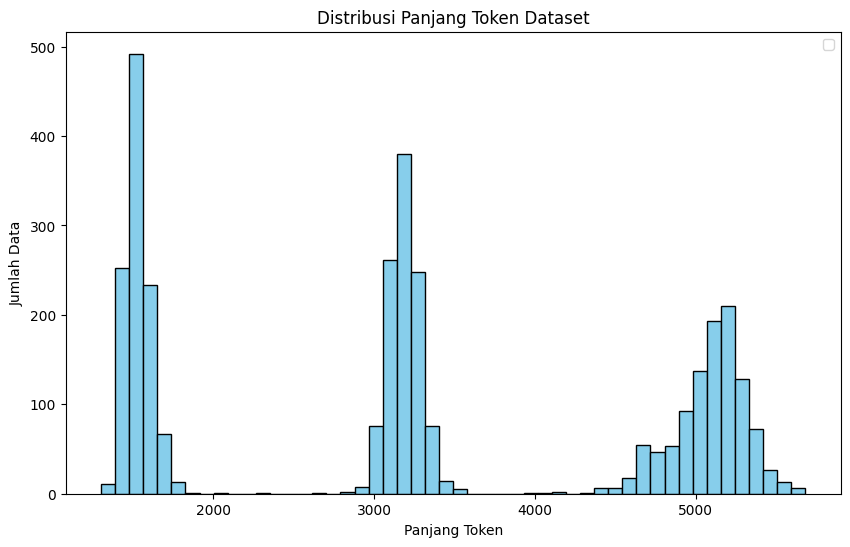

In [ ]:
# visualize data distribution
import matplotlib.pyplot as plt

lengths = [len(tokenizer.tokenize(t)) for t in clean_dataset["text"]]

di_atas_1024 = sum(1 for l in lengths if l > 1024)
persentase = (di_atas_1024 / len(lengths)) * 100

print(f"Total data: {len(lengths)}")
print(f"Data terpanjang: {max(lengths)} token")

plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribusi Panjang Token Dataset')
plt.xlabel('Panjang Token')
plt.ylabel('Jumlah Data')
plt.legend()
plt.show()

## 5. Training the Model

In [ ]:
# training for zero-shot
from trl import SFTTrainer
from transformers import TrainingArguments

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = clean_dataset,
    dataset_text_field = "text",
    max_seq_length = 4192,
    dataset_num_proc = None,
    args = TrainingArguments(
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 8,
        warmup_steps = 5,
        num_train_epochs = 2,
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
    ),
)

# start training
trainer_stats = trainer.train()

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/3210 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,210 | Num Epochs = 2 | Total steps = 804
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 3,407,872 of 1,239,222,272 (0.28% trained)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


Step,Training Loss
1,2.001200
2,2.012300
3,2.034100
4,2.031500
5,2.066700
6,2.003800
7,1.922600
8,1.726900
9,1.806000
10,1.652000


wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run


In [ ]:
# training for one-shot
from trl import SFTTrainer
from transformers import TrainingArguments

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = clean_dataset,
    dataset_text_field = "text",
    max_seq_length = 5800,
    dataset_num_proc = None,
    args = TrainingArguments(
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 8,
        warmup_steps = 5,
        num_train_epochs = 2,
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
    ),
)

# start training
trainer_stats = trainer.train()

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/3210 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,210 | Num Epochs = 2 | Total steps = 804
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 9,175,040 of 3,221,924,864 (0.28% trained)


Step,Training Loss
1,1.862000
2,1.815100
3,1.833100
4,1.942000
5,1.847900
6,1.851900
7,1.712800
8,1.598800
9,1.580500
10,1.478400


wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run


In [ ]:
# saving fine-tuned zero-shot model
model.save_pretrained("/content/drive/MyDrive/Skripsi/Fine-Tuned-3B-4192") # adjust the path
tokenizer.save_pretrained("/content/drive/MyDrive/Skripsi/Fine-Tuned-3B-4192") # adjust the path

('/content/drive/MyDrive/Skripsi/Fine-Tuned-3B-4192/tokenizer_config.json',
 '/content/drive/MyDrive/Skripsi/Fine-Tuned-3B-4192/special_tokens_map.json',
 '/content/drive/MyDrive/Skripsi/Fine-Tuned-3B-4192/chat_template.jinja',
 '/content/drive/MyDrive/Skripsi/Fine-Tuned-3B-4192/tokenizer.json')

In [ ]:
# saving fine-tuned one-shot model
model.save_pretrained("/content/drive/MyDrive/Skripsi/Fine-Tuned-3B-5800-One-Shot") # adjust the path
tokenizer.save_pretrained("/content/drive/MyDrive/Skripsi/Fine-Tuned-3B-5800-One-Shot") # adjust the path

('/content/drive/MyDrive/Skripsi/Fine-Tuned-3B-5800-One-Shot/tokenizer_config.json',
 '/content/drive/MyDrive/Skripsi/Fine-Tuned-3B-5800-One-Shot/special_tokens_map.json',
 '/content/drive/MyDrive/Skripsi/Fine-Tuned-3B-5800-One-Shot/chat_template.jinja',
 '/content/drive/MyDrive/Skripsi/Fine-Tuned-3B-5800-One-Shot/tokenizer.json')

## 6. Inferencing Results

### Without In-Context Learning

In [ ]:
import json
import pandas as pd
from datasets import Dataset

instruction = """
Kamu adalah asisten yang ahli dalam pembentukan Graf Pengetahuan (Knowledge Graph). Tugasmu adalah mengonversi teks secara langsung menjadi representasi Resource Description Framework (RDF) secara akurat, eksplisit, dan terstruktur.

Instruksi:
- Buat triplet relasi utama antar entitas yang ditemukan dalam teks.
- Gunakan prefix kosong : (http://example.org/) untuk entitas buatan, serta gunakan prefix standar rdf:, rdfs:, dan xsd:.
- Ubah spasi pada nama entitas dan relasi menjadi format Snake_Case dengan awalan huruf kapital.
- Langsung hasilkan code block sintaks Turtle (.ttl) tanpa penjelasan atau kata pembuka apa pun.

Sajikan jawaban dengan format persis seperti berikut:
@prefix : <http://example.org/> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

# Triples
:Node_Utama :memilikiRelasi :Elemen_A .
:Elemen_A :berelasiDengan :Entitas_Lain .
...

# Definisi Node
:Node_Utama rdf:type :Topik_Utama ;
    rdfs:label "Deskripsi atau nilai dari node utama." .

:Elemen_A rdf:type :Kategori_Elemen ;
    rdfs:label "Deskripsi elemen tersebut." .
...
"""

def load_json(path):
    with open(path, 'r') as f:
        return json.load(f)

combined_data = []
input_data = load_json('/content/drive/MyDrive/dataset_clean.json') # adjust the path

for item in input_data:
    item_id = item['id']

    combined_data.append({
        "id": item_id,
        "instruction": instruction,
        "input": item['text'],
    })

dataset = Dataset.from_list(combined_data)

In [ ]:
import pandas as pd
from unsloth import FastLanguageModel
import torch
import os

max_seq_length = 4192
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "/content/drive/MyDrive/Skripsi/Fine-Tuned-3B-4192", # adjust the path
    max_seq_length = max_seq_length,
    load_in_4bit = True,
)

terminators = [
    tokenizer.eos_token_id,
    tokenizer.convert_tokens_to_ids("<|eot_id|>")
]

# saving progress
checkpoint_path = "/content/drive/MyDrive/Skripsi/progress_evaluasi.csv" # adjust the path
evaluated_data = []

if os.path.exists(checkpoint_path):
    print(f" Mengemban data progres sebelumnya dari {checkpoint_path}...")
    df_checkpoint = pd.read_csv(checkpoint_path)
    evaluated_data = df_checkpoint.to_dict(orient="records")
    processed_ids = [str(item["Text ID"]) for item in evaluated_data]
    print(f" Berhasil memuat {len(processed_ids)} data yang sudah diproses sebelumnya.")
else:
    processed_ids = []

print(f"\n=== Memulai Inferensi Dataset (Total: {len(dataset)} data) ===")

for i, item in enumerate(dataset):
    item_id = str(item["id"])
    instruction_text = item["instruction"]
    text_input = item["input"]

    if item_id in processed_ids:
        continue

    print(f"Processing ID {item_id} ({i+1} of {len(dataset)})...")

    formatted_prompt = tokenizer.apply_chat_template(
        [
            {"role": "system", "content": instruction_text},
            {"role": "user", "content": text_input}
        ],
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(formatted_prompt, return_tensors="pt").to("cuda")
    input_len = inputs["input_ids"].shape[1]

    # inferencing base model
    with model.disable_adapter():
        base_outputs = model.generate(
            **inputs,
            max_new_tokens=4192,
            do_sample=False,
            eos_token_id=terminators,
            pad_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.2
        )
    base_text = tokenizer.decode(base_outputs[0][input_len:], skip_special_tokens=True)

    # inferencing fine-tuned model
    finetuned_outputs = model.generate(
        **inputs,
        max_new_tokens=4192,
        do_sample=False,
        eos_token_id=terminators,
        pad_token_id=tokenizer.eos_token_id,
        repetition_penalty=1.2
    )
    finetuned_text = tokenizer.decode(finetuned_outputs[0][input_len:], skip_special_tokens=True)

    evaluated_data.append({
        "Text ID": item_id,
        "Original Text": text_input,
        "Base Model": base_text.strip(),
        "Fine-Tuned Model": finetuned_text.strip()
    })

    # autosaving per 5 data
    current_count = len(evaluated_data)
    if current_count % 5 == 0 or (i + 1) == len(dataset):
        print(f"\n💾 [AUTO-SAVE] Menyimpan progres hingga data ke-{current_count} ke Drive...")

        progress_df = pd.DataFrame(evaluated_data)
        progress_df.to_csv(checkpoint_path, index=False)

        print("💾 Progress berhasil diamankan secara berkala.\n")

results_df = pd.DataFrame(evaluated_data)
print(f"=== Seluruh Inferensi Selesai! Total: {len(results_df)} baris data disimpan ===")

==((====))==  Unsloth 2026.5.5: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!

=== Memulai Inferensi Dataset (Total: 45 data) ===
Processing ID data_001 (1 of 45)...
Processing ID data_002 (2 of 45)...
Processing ID data_003 (3 of 45)...
Processing ID data_004 (4 of 45)...
Processing ID data_005 (5 of 45)...

💾 [AUTO-SAVE] Menyimpan progres hingga data ke-5 ke Drive...
💾 Progress berhasil diamankan secara berkala.

Processing ID data_006 (6 of 45)...
Processing ID data_007 (7 of 45)...
Processing ID data_008 (8 of 45)...
Processing ID data_009 (9 of 45)...
Processing ID data_010 (10 of 45)...

💾 [AUTO-SAVE] Menyimpan prog

In [ ]:
results_df.to_csv('/content/drive/MyDrive/Skripsi/evaluationresults_zeroshot.csv', index=False)

### With In-Context Learning

In [ ]:
import json
import pandas as pd
from datasets import Dataset
import re

instruction = """
Kamu adalah asisten yang ahli dalam pembentukan Graf Pengetahuan (Knowledge Graph). Tugasmu adalah mengonversi teks secara langsung menjadi representasi Resource Description Framework (RDF) secara akurat, eksplisit, dan terstruktur.

Instruksi:
- Buat triplet relasi utama antar entitas yang ditemukan dalam teks.
- Gunakan prefix kosong : (http://example.org/) untuk entitas buatan, serta gunakan prefix standar rdf:, rdfs:, dan xsd:.
- Ubah spasi pada nama entitas dan relasi menjadi format Snake_Case dengan awalan huruf kapital.
- Langsung hasilkan code block sintaks Turtle (.ttl) tanpa penjelasan atau kata pembuka apa pun.

Sajikan jawaban dengan format persis seperti berikut:
@prefix : <http://example.org/> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

# Triples
:Node_Utama :memilikiRelasi :Elemen_A .
:Elemen_A :berelasiDengan :Entitas_Lain .
...

# Definisi Node
:Node_Utama rdf:type :Topik_Utama ;
    rdfs:label "Deskripsi atau nilai dari node utama." .

:Elemen_A rdf:type :Kategori_Elemen ;
    rdfs:label "Deskripsi elemen tersebut." .
...
"""

additional_instruction = {
    "abstrak": """
---

Sebagai panduan, berikut 1 buah contoh teks beserta format serta hasil RDF dan analisis teks yang diharapkan:

CONTOH JUDUL TEKS: Pengaruh Iklim Sekolah dan Pemantauan Orang Tua terhadap Perilaku Perundungan Pelajar

CONTOH ISI TEKS:
Perilaku perundungan di sekolah masih menjadi persoalan serius di Indonesia. Penelitian untuk memperoleh faktor-faktor yang dapat mengurangi perilaku perundungan pelajar perlu dilakukan sebagai dasar untuk merancang program intervensi. Penelitian ini bertujuan untuk mendapatkan gambaran perundungan yang terjadi pada pelajar sekolah dan kemudian menguji pengaruh iklim sekolah dan pemantauan orang tua terhadap perilaku perundungan. Penelitian ini menggunakan metode penelitian kuantitatif. Data yang digunakan adalah data primer dengan menyebarkan kuesioner kepada para pelajar sekolah. Analisis data dilakukan dengan menerapkan regresi logistik. Hasil penelitian memperlihatkan bahwa jenis perundungan yang menonjol dijumpai adalah perundungan verbal dan relasional. Dengan menerapkan analisis regresi logistik, hasil penelitian menunjukkan bahwa iklim sekolah yang positif menurunkan kemungkinan para pelajar untuk menjadi korban perundungan. Selain itu, iklim sekolah yang positif dan pemantauan orang tua mengurangi kemungkinan pelajar untuk menjadi pelaku perundungan. Pendidikan karakter merupakan salah satu upaya sekolah untuk mencegah terjadinya perundungan di sekolah. Dengan demikian, baik pihak sekolah maupun orang tua berperan dalam mengurangi maraknya perilaku perundungan di kalangan remaja pelajar.

CONTOH HASIL RDF TEKS:
@prefix : <http://example.org/> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

# Triples
:Penelitian :memilikiMasalah :Masalah_Penelitian .
:Penelitian :bertopik :Topik_Penelitian .
:Penelitian :menggunakanMetodologi :Metodologi_Penelitian .
:Penelitian :menggunakanSumberData :Sumber_Data_Penelitian .
:Penelitian :menghasilkan :Hasil_Penelitian_1, :Hasil_Penelitian_2, :Hasil_Penelitian_3, :Hasil_Penelitian_4, :Hasil_Penelitian_5 .
:Penelitian :untukMemperolehFaktorYangMengurangi :Perilaku_Perundungan .
:Penelitian :mengujiPengaruh :Iklim_Sekolah, :Pemantauan_Orang_Tua .
:Penelitian :menggunakan :Data_Primer, :Kuesioner, :Metode_Penelitian_Kuantitatif .
:Perilaku_Perundungan :menjadiPersoalanDi :Indonesia .
:Kuesioner :disebarKepada :Pelajar .
:Analisis_Data :menggunakan :Regresi_Logistik .
:Perundungan :memilikiJenis :Perundungan_Relasional, :Perundungan_Verbal .
:Iklim_Sekolah :mengurangiKemungkinanMenjadi :Korban_Perundungan, :Pelaku_Perundungan .
:Pemantauan_Orang_Tua :mengurangiKemungkinanMenjadi :Pelaku_Perundungan .
:Pendidikan_Karakter :mencegahTerjadinya :Perilaku_Perundungan .
:Sekolah :berperanDalamMengurangi :Perilaku_Perundungan .
:Orang_Tua :berperanDalamMengurangi :Perilaku_Perundungan .

# Definisi Node Non-Entity
:Masalah_Penelitian rdf:type :Problem ;
    rdfs:label "Perilaku perundungan di sekolah masih menjadi persoalan serius di Indonesia dan perlunya dasar untuk merancang program intervensi melalui identifikasi faktor-faktor yang dapat mengurangi perilaku tersebut." .

:Topik_Penelitian rdf:type :Topic ;
    rdfs:label "Pendidikan / Psikologi Pendidikan" .

:Metodologi_Penelitian rdf:type :Methodology ;
    rdfs:label "Kuantitatif dengan teknik analisis data regresi logistik" .

:Sumber_Data_Penelitian rdf:type :DataSource ;
    rdfs:label "Data primer yang diperoleh melalui penyebaran kuesioner kepada para pelajar sekolah" .

:Hasil_Penelitian_1 rdf:type :Result ;
    rdfs:label "Jenis perundungan yang menonjol adalah perundungan verbal dan relasional." .

:Hasil_Penelitian_2 rdf:type :Result ;
    rdfs:label "Iklim sekolah yang positif terbukti menurunkan kemungkinan pelajar menjadi korban perundungan." .

:Hasil_Penelitian_3 rdf:type :Result ;
    rdfs:label "Kombinasi iklim sekolah yang positif dan pemantauan orang tua secara efektif mengurangi kemungkinan pelajar menjadi pelaku perundungan." .

:Hasil_Penelitian_4 rdf:type :Result ;
    rdfs:label "Pendidikan karakter diidentifikasi sebagai salah satu upaya pencegahan di lingkungan sekolah." .

:Hasil_Penelitian_5 rdf:type :Result ;
    rdfs:label "Kerja sama antara pihak sekolah dan orang tua sangat krusial dalam mengurangi perilaku perundungan di kalangan remaja pelajar." .
---
""",

    "berita": """
---

Sebagai panduan, berikut 1 buah contoh teks beserta format serta hasil RDF dan analisis teks yang diharapkan:

CONTOH JUDUL TEKS: Jokowi Lantik KSAD Baru di Istana Hari Ini

CONTOH ISI TEKS:
Presiden Joko Widodo (Jokowi) dijadwalkan akan melantik Kepala Staf Angkatan Darat (KSAD) pada Rabu (29/11) di Istana Negara, Jakarta. Informasi itu dibenarkan oleh Ketua Komisi I DPR RI Meutya Hafid. "Ya betul (Jokowi lantik KSAD)," kata Meutya lewat pesan singkat, Selasa (28/11) malam. Namun demikian, Meutya belum memberitahu siapa perwira tinggi yang bakal mengisi kursi KSAD. Sebelumnya, salah satu yang disebut berpeluang besar menjadi KSAD adalah Panglima Komando Cadangan Strategis Angkatan Darat (Pangkostrad) Letjen Maruli Simanjuntak. Presiden Joko Widodo turut membenarkan Maruli merupakan satu dari sejumlah nama jenderal yang masuk dalam bursa KSAD. "Salah satu kandidat," kata Jokowi di Indonesia Arena, Jakarta, Sabtu (25/11). Posisi KSAD kosong setelah Jenderal Agus Subiyanto dilantik menjadi Panglima TNI. Agus sempat menjabat sebagai KSAD menggantikan Jenderal Dudung Abdurachman yang pensiun. Beberapa hari menjabat KSAD, Agus diusulkan Presiden Jokowi menjadi Panglima TNI. Ia baru dilantik pada pekan lalu.

CONTOH HASIL RDF TEKS:
@prefix : <http://example.org/> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

# Triples
:Teks_Berita :memiliki5w1h :Node_5W1H .
:Teks_Berita :memilikisentimen :Sentimen_Positif .
:Teks_Berita :berisikutipan :Kutipan_1, :Kutipan_2 .
:Teks_Berita :memilikikronologi :Kronologi_1, :Kronologi_2, :Kronologi_3, :Kronologi_4, :Kronologi_5, :Kronologi_6, :Kronologi_7, :Kronologi_8 .
:Node_5W1H :memiliki :How, :What, :When, :Where, :Who, :Why .
:What :merujuk_pada :Presiden_Joko_Widodo_Dijadwalkan_Melantik_Kepala_Staf_Angkatan_Darat_Ksad_Baru .
:Who :merujuk_pada :Jenderal_Agus_Subiyanto, :Jenderal_Dudung_Abdurachman, :Letjen_Maruli_Simanjuntak, :Meutya_Hafid, :Presiden_Joko_Widodo .
:When :merujuk_pada :Rabu_2911_Untuk_Pelantikan, :Sabtu_2511_Untuk_Pernyataan_Jokowi, :Selasa_2811_Malam_Untuk_Konfirmasi_Meutya .
:Where :merujuk_pada :Istana_Negara, :Jakarta, :Jakarta_Indonesia_Arena .
:Why :merujuk_pada :Karena_Posisi_Ksad_Kosong_Setelah_Jenderal_Agus_Subiyanto_Dilantik_Menjadi_Panglima_Tni .
:How :merujuk_pada :Jokowi_Akan_Melantik_Ksad_Baru_Di_Istana_Negara_Setelah_Mempertimbangkan_Sejumlah_Kandidat_Dari_Bursa_Ksad, :Salah_Satunya_Letjen_Maruli_Simanjuntak .
:Kutipan_1 :pernyataan :Ketua_Komisi_I_Dpr_Ri_Meutya_Hafid .
:Kutipan_2 :pernyataan :Presiden_Joko_Widodo_Jokowi .
:Kronologi_1 :dilanjutkanDengan :Kronologi_2 .
:Kronologi_2 :dilanjutkanDengan :Kronologi_3 .
:Kronologi_3 :dilanjutkanDengan :Kronologi_4 .
:Kronologi_4 :dilanjutkanDengan :Kronologi_5 .
:Kronologi_5 :dilanjutkanDengan :Kronologi_6 .
:Kronologi_6 :dilanjutkanDengan :Kronologi_7 .
:Kronologi_7 :berakhirDengan :Kronologi_8 .
:Presiden_Joko_Widodo_Jokowi :akanMelantik :Kepala_Staf_Angkatan_Darat_Ksad .
:Presiden_Joko_Widodo_Jokowi :membenarkan :Panglima_Komando_Cadangan_Strategis_Angkatan_Darat_Pangkostrad_Letjen_Maruli_Simanjuntak .
:Presiden_Joko_Widodo_Jokowi :menyampaikanDi :Indonesia_Arena .
:Presiden_Joko_Widodo_Jokowi :menyampaikanPada :Sabtu_2511 .
:Presiden_Joko_Widodo_Jokowi :mengusulkan :Jenderal_Agus_Subiyanto .
:Pelantikan_Ksad :berlangsungPada :Rabu_2911 .
:Pelantikan_Ksad :berlangsungDi :Istana_Negara .
:Istana_Negara :beradaDi :Jakarta .
:Ketua_Komisi_I_Dpr_Ri_Meutya_Hafid :membenarkan :Pelantikan_Ksad .
:Ketua_Komisi_I_Dpr_Ri_Meutya_Hafid :menyampaikanLewat :Pesan_Singkat .
:Ketua_Komisi_I_Dpr_Ri_Meutya_Hafid :menyampaikanPada :Selasa_2811_Malam .
:Perwira_Tinggi :mengisi :Posisi_Ksad .
:Panglima_Komando_Cadangan_Strategis_Angkatan_Darat_Pangkostrad_Letjen_Maruli_Simanjuntak :masukDalam :Bursa_Ksad .
:Panglima_Komando_Cadangan_Strategis_Angkatan_Darat_Pangkostrad_Letjen_Maruli_Simanjuntak :merupakan :Kandidat_Ksad .
:Indonesia_Arena :beradaDi :Jakarta .
:Posisi_Ksad :kosongSetelah :Jenderal_Agus_Subiyanto .
:Jenderal_Agus_Subiyanto :dilantikMenjadi :Panglima_Tni .
:Jenderal_Agus_Subiyanto :sebelumnyaMenjabatSebagai :Kepala_Staf_Angkatan_Darat_Ksad .
:Jenderal_Agus_Subiyanto :menggantikan :Jenderal_Dudung_Abdurachman .
:Jenderal_Agus_Subiyanto :diusulkanMenjadi :Panglima_Tni .
:Jenderal_Agus_Subiyanto :dilantikPada :Pekan_Lalu .
:Jenderal_Dudung_Abdurachman :mengalami :Pensiun .

# Definisi Node Non-Entity
:Node_5W1H rdf:type :5W1H_Utama ;
    rdfs:label "5W1H" .

:What rdf:type :5W1H_Elemen ;
    rdfs:label "What" .

:Who rdf:type :5W1H_Elemen ;
    rdfs:label "Who" .

:When rdf:type :5W1H_Elemen ;
    rdfs:label "When" .

:Where rdf:type :5W1H_Elemen ;
    rdfs:label "Where" .

:Why rdf:type :5W1H_Elemen ;
    rdfs:label "Why" .

:How rdf:type :5W1H_Elemen ;
    rdfs:label "How" .

:Sentimen_Positif rdf:type :Sentiment ;
    rdfs:label "Positif: Proses pelantikan menunjukkan keberlanjutan kepemimpinan dan pengisian posisi strategis di TNI" .

:Kutipan_1 rdf:type :Quotes ;
    rdfs:label "\"Ya betul (Jokowi lantik KSAD)\"" .

:Kutipan_2 rdf:type :Quotes ;
    rdfs:label "\"Salah satu kandidat\"" .

:Kronologi_1 rdf:type :Chronology ;
    rdfs:label "Jenderal Dudung Abdurachman pensiun dari jabatan KSAD" .

:Kronologi_2 rdf:type :Chronology ;
    rdfs:label "Jenderal Agus Subiyanto menjabat sebagai KSAD menggantikan Dudung" .

:Kronologi_3 rdf:type :Chronology ;
    rdfs:label "Beberapa hari setelah menjabat KSAD, Agus diusulkan Presiden Jokowi menjadi Panglima TNI" .

:Kronologi_4 rdf:type :Chronology ;
    rdfs:label "Jenderal Agus Subiyanto dilantik menjadi Panglima TNI pada pekan lalu" .

:Kronologi_5 rdf:type :Chronology ;
    rdfs:label "Posisi KSAD menjadi kosong" .

:Kronologi_6 rdf:type :Chronology ;
    rdfs:label "Letjen Maruli Simanjuntak disebut sebagai salah satu kandidat kuat KSAD" .

:Kronologi_7 rdf:type :Chronology ;
    rdfs:label "Jokowi membenarkan Maruli masuk dalam bursa KSAD pada Sabtu (25/11)" .

:Kronologi_8 rdf:type :Chronology ;
    rdfs:label "Meutya Hafid membenarkan Jokowi akan melantik KSAD pada Rabu (29/11)" .
---
""",

    "tweet": """
---

Sebagai panduan, berikut 1 buah contoh teks beserta format serta hasil RDF dan analisis teks yang diharapkan:

CONTOH TEKS:
I GOT RACIAL BULLYING FOR THE VERY FIRST TIME HERE IN THE US.
Aku ga nyangka dapet tindakan rasisme dari SESAMA ORANG INDONESIA, ORANG BALI.

Disclaimer:
Aku gak menjelekkan orang Bali disini, aku cuma cerita tindakan kurang mengenakkan yang aku dapatkan dari seseorang, hari ini.

CONTOH HASIL RDF TEKS:
@prefix : <http://example.org/> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

# Triples
:Unggahan :mengenai :Aku .
:Unggahan :memilikitopik :Topik .
:Unggahan :memilikisentimen :Negatif .
:Negatif :memilikiAlasan :Penulis_Tidak_Menyangka_Akan_Mendapatkan_Perilaku_Rasisme_Oleh_Sesama_Orang_Indonesia .
:Aku :mendapatkan :Racial_Bullying .
:Aku :tidakMenjelekkan :Orang_Bali .
:Racial_Bullying :terjadiDi :Us .
:Racial_Bullying :dilakukanOleh :Orang_Bali, :Orang_Indonesia .

# Definisi Node Non-Entity
:Topik rdf:type :Topic ;
    rdfs:label "Aku mengalami racial bullying oleh sesama orang Indonesia, secara spesifik orang Bali" .

:Negatif rdf:type :Sentiment ;
    rdfs:label "Negatif" .

:Penulis_Tidak_Menyangka_Akan_Mendapatkan_Perilaku_Rasisme_Oleh_Sesama_Orang_Indonesia rdf:type :Sentiment ;
    rdfs:label "penulis tidak menyangka akan mendapatkan perilaku rasisme oleh sesama orang indonesia" .
---
"""
}

def load_json(path):
    with open(path, 'r') as f:
        return json.load(f)

combined_data = []
input_data = load_json('/content/drive/MyDrive/dataset_clean.json') # adjust the path

def get_category_by_id(item_id):
    match = re.search(r'\d+', item_id)
    if not match:
        return None

    id_num = int(match.group())

    if 1 <= id_num <= 15:
        return "berita"
    elif 16 <= id_num <= 30:
        return "abstrak"
    elif 31 <= id_num <= 45:
        return "tweet"
    return None

for item in input_data:
    item_id = item['id']

    cat = get_category_by_id(item_id)

    if cat:
        final_instruction = instruction + additional_instruction.get(cat, "")

        combined_data.append({
            "id": item_id,
            "instruction": final_instruction,
            "input": item['text'],
        })

dataset = Dataset.from_list(combined_data)

In [ ]:
import pandas as pd
from unsloth import FastLanguageModel
import torch
import os

max_seq_length = 5800
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "/content/drive/MyDrive/Skripsi/Fine-Tuned-3B-5800-One-Shot", # adjust the path
    max_seq_length = max_seq_length,
    load_in_4bit = True,
)

terminators = [
    tokenizer.eos_token_id,
    tokenizer.convert_tokens_to_ids("<|eot_id|>")
]

# saving progress
checkpoint_path = "/content/drive/MyDrive/Skripsi/progress_evaluasi_oneshot.csv" # adjust the path
evaluated_data = []

if os.path.exists(checkpoint_path):
    print(f" Mengemban data progres sebelumnya dari {checkpoint_path}...")
    df_checkpoint = pd.read_csv(checkpoint_path)
    evaluated_data = df_checkpoint.to_dict(orient="records")
    processed_ids = [str(item["Text ID"]) for item in evaluated_data]
    print(f" Berhasil memuat {len(processed_ids)} data yang sudah diproses sebelumnya.")
else:
    processed_ids = []

print(f"\n=== Memulai Inferensi Dataset (Total: {len(dataset)} data) ===")

for i, item in enumerate(dataset):
    item_id = str(item["id"])
    instruction_text = item["instruction"]
    text_input = item["input"]

    if item_id in processed_ids:
        continue

    print(f"Processing ID {item_id} ({i+1} of {len(dataset)})...")

    formatted_prompt = tokenizer.apply_chat_template(
        [
            {"role": "system", "content": instruction_text},
            {"role": "user", "content": text_input}
        ],
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(formatted_prompt, return_tensors="pt").to("cuda")
    input_len = inputs["input_ids"].shape[1]

    # inferencing base model
    with model.disable_adapter():
        base_outputs = model.generate(
            **inputs,
            max_new_tokens=5800,
            do_sample=False,
            eos_token_id=terminators,
            pad_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.2
        )
    base_text = tokenizer.decode(base_outputs[0][input_len:], skip_special_tokens=True)

    # inferencing fine-tuned model
    finetuned_outputs = model.generate(
        **inputs,
        max_new_tokens=5800,
        do_sample=False,
        eos_token_id=terminators,
        pad_token_id=tokenizer.eos_token_id,
        repetition_penalty=1.2
    )
    finetuned_text = tokenizer.decode(finetuned_outputs[0][input_len:], skip_special_tokens=True)

    evaluated_data.append({
        "Text ID": item_id,
        "Original Text": text_input,
        "Base Model": base_text.strip(),
        "Fine-Tuned Model": finetuned_text.strip()
    })

    current_count = len(evaluated_data)
    if current_count % 5 == 0 or (i + 1) == len(dataset):
        print(f"\n💾 [AUTO-SAVE] Menyimpan progres hingga data ke-{current_count} ke Drive...")

        progress_df = pd.DataFrame(evaluated_data)
        progress_df.to_csv(checkpoint_path, index=False)

        print("💾 Progress berhasil diamankan secara berkala.\n")

results_df = pd.DataFrame(evaluated_data)
print(f"=== Seluruh Inferensi Selesai! Total: {len(results_df)} baris data disimpan ===")

==((====))==  Unsloth 2026.5.5: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!

=== Memulai Inferensi Dataset (Total: 45 data) ===
Processing ID data_001 (1 of 45)...
Processing ID data_002 (2 of 45)...
Processing ID data_003 (3 of 45)...
Processing ID data_004 (4 of 45)...
Processing ID data_005 (5 of 45)...

💾 [AUTO-SAVE] Menyimpan progres hingga data ke-5 ke Drive...
💾 Progress berhasil diamankan secara berkala.

Processing ID data_006 (6 of 45)...
Processing ID data_007 (7 of 45)...
Processing ID data_008 (8 of 45)...
Processing ID data_009 (9 of 45)...
Processing ID data_010 (10 of 45)...

💾 [AUTO-SAVE] Menyimpan prog

In [ ]:
results_df.to_csv('/content/drive/MyDrive/Skripsi/evaluationresults_oneshot.csv', index=False) # adjust the path

### Benchmarking

#### Without In-Context Learning

In [ ]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 4.9 MB/s eta 0:00:00


In [ ]:
import json
import pandas as pd
from datasets import Dataset

instruction = """
Kamu adalah asisten yang ahli dalam pembentukan Graf Pengetahuan (Knowledge Graph). Tugasmu adalah mengonversi teks secara langsung menjadi representasi Resource Description Framework (RDF) secara akurat, eksplisit, dan terstruktur.

Instruksi:
- Buat triplet relasi utama antar entitas yang ditemukan dalam teks.
- Gunakan prefix kosong : (http://example.org/) untuk entitas buatan, serta gunakan prefix standar rdf:, rdfs:, dan xsd:.
- Ubah spasi pada nama entitas dan relasi menjadi format Snake_Case dengan awalan huruf kapital.
- Langsung hasilkan code block sintaks Turtle (.ttl) tanpa penjelasan atau kata pembuka apa pun.

Sajikan jawaban dengan format persis seperti berikut:
@prefix : <http://example.org/> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

# Triples
:Node_Utama :memilikiRelasi :Elemen_A .
:Elemen_A :berelasiDengan :Entitas_Lain .
...

# Definisi Node
:Node_Utama rdf:type :Topik_Utama ;
    rdfs:label "Deskripsi atau nilai dari node utama." .

:Elemen_A rdf:type :Kategori_Elemen ;
    rdfs:label "Deskripsi elemen tersebut." .
...
"""

def load_json(path):
    with open(path, 'r') as f:
        return json.load(f)

combined_data = []
input_data = load_json('/content/drive/MyDrive/dataset_clean.json') # adjust the path

for item in input_data:
    item_id = item['id']

    combined_data.append({
        "id": item_id,
        "instruction": instruction,
        "input": item['text'],
    })

dataset = Dataset.from_list(combined_data)

In [ ]:
import os
import pandas as pd
from groq import Groq
from google.colab import userdata

GROQ_API_KEY = userdata.get('GROQ_API_KEY')
client = Groq(api_key=GROQ_API_KEY)

GROQ_MODEL = "openai/gpt-oss-120b"

checkpoint_path = "/content/drive/MyDrive/Skripsi/progress_evaluasi_groq.csv" # adjust the path
evaluated_data = []

if os.path.exists(checkpoint_path):
    print(f" Melanjutkan data progres sebelumnya dari {checkpoint_path}...")
    df_checkpoint = pd.read_csv(checkpoint_path)
    evaluated_data = df_checkpoint.to_dict(orient="records")
    processed_ids = [str(item["Text ID"]) for item in evaluated_data]
    print(f" Berhasil memuat {len(processed_ids)} data yang sudah diproses sebelumnya.")
else:
    processed_ids = []

print(f"\n=== Memulai Inferensi Dataset via Groq API (Total: {len(dataset)} data) ===")

for i, item in enumerate(dataset):
    item_id = str(item["id"])
    instruction_text = item["instruction"]
    text_input = item["input"]

    if item_id in processed_ids:
        continue

    print(f"Processing ID {item_id} ({i+1} of {len(dataset)})...")

    try:
        completion = client.chat.completions.create(
            model=GROQ_MODEL,
            messages=[
                {"role": "system", "content": instruction_text},
                {"role": "user", "content": text_input}
            ],
            temperature=0.0,
            max_tokens=4192,
        )

        groq_response = completion.choices[0].message.content

        evaluated_data.append({
            "Text ID": item_id,
            "Original Text": text_input,
            "Instruction": instruction_text,
            f"Groq {GROQ_MODEL}": groq_response.strip()
        })

    except Exception as e:
        print(f"❌ Error pada ID {item_id}: {e}")
        print("Menyelamatkan data yang sudah ada sebelum berhenti...")
        progress_df = pd.DataFrame(evaluated_data)
        progress_df.to_csv(checkpoint_path, index=False)
        break

    current_count = len(evaluated_data)
    if current_count % 5 == 0 or (i + 1) == len(dataset):
        print(f"\n💾 [AUTO-SAVE] Menyimpan progres hingga data ke-{current_count} ke Drive...")

        progress_df = pd.DataFrame(evaluated_data)
        progress_df.to_csv(checkpoint_path, index=False)

        print("💾 Progress berhasil diamankan secara berkala.\n")

if evaluated_data:
    results_df = pd.DataFrame(evaluated_data)
    print(f"=== Seluruh Inferensi Selesai! Total: {len(results_df)} baris data disimpan ===")


=== Memulai Inferensi Dataset via Groq API (Total: 45 data) ===
Processing ID data_001 (1 of 45)...
Processing ID data_002 (2 of 45)...
Processing ID data_003 (3 of 45)...
Processing ID data_004 (4 of 45)...
Processing ID data_005 (5 of 45)...

💾 [AUTO-SAVE] Menyimpan progres hingga data ke-5 ke Drive...
💾 Progress berhasil diamankan secara berkala.

Processing ID data_006 (6 of 45)...
Processing ID data_007 (7 of 45)...
Processing ID data_008 (8 of 45)...
Processing ID data_009 (9 of 45)...
Processing ID data_010 (10 of 45)...

💾 [AUTO-SAVE] Menyimpan progres hingga data ke-10 ke Drive...
💾 Progress berhasil diamankan secara berkala.

Processing ID data_011 (11 of 45)...
Processing ID data_012 (12 of 45)...
Processing ID data_013 (13 of 45)...
Processing ID data_014 (14 of 45)...
Processing ID data_015 (15 of 45)...

💾 [AUTO-SAVE] Menyimpan progres hingga data ke-15 ke Drive...
💾 Progress berhasil diamankan secara berkala.

Processing ID data_016 (16 of 45)...
Processing ID data_017 

In [ ]:
results_df.to_csv('/content/drive/MyDrive/Skripsi/evaluationresults_zeroshot_groq.csv', index=False)

#### With In-Context Learning

In [ ]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 3.1 MB/s eta 0:00:00


In [ ]:
import json
import pandas as pd
from datasets import Dataset
import re

instruction = """
Kamu adalah asisten yang ahli dalam pembentukan Graf Pengetahuan (Knowledge Graph). Tugasmu adalah mengonversi teks secara langsung menjadi representasi Resource Description Framework (RDF) secara akurat, eksplisit, dan terstruktur.

Instruksi:
- Buat triplet relasi utama antar entitas yang ditemukan dalam teks.
- Gunakan prefix kosong : (http://example.org/) untuk entitas buatan, serta gunakan prefix standar rdf:, rdfs:, dan xsd:.
- Ubah spasi pada nama entitas dan relasi menjadi format Snake_Case dengan awalan huruf kapital.
- Langsung hasilkan code block sintaks Turtle (.ttl) tanpa penjelasan atau kata pembuka apa pun.

Sajikan jawaban dengan format persis seperti berikut:
@prefix : <http://example.org/> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

# Triples
:Node_Utama :memilikiRelasi :Elemen_A .
:Elemen_A :berelasiDengan :Entitas_Lain .
...

# Definisi Node
:Node_Utama rdf:type :Topik_Utama ;
    rdfs:label "Deskripsi atau nilai dari node utama." .

:Elemen_A rdf:type :Kategori_Elemen ;
    rdfs:label "Deskripsi elemen tersebut." .
...
"""

additional_instruction = {
    "abstrak": """
---

Sebagai panduan, berikut 1 buah contoh teks beserta format serta hasil RDF dan analisis teks yang diharapkan:

CONTOH JUDUL TEKS: Pengaruh Iklim Sekolah dan Pemantauan Orang Tua terhadap Perilaku Perundungan Pelajar

CONTOH ISI TEKS:
Perilaku perundungan di sekolah masih menjadi persoalan serius di Indonesia. Penelitian untuk memperoleh faktor-faktor yang dapat mengurangi perilaku perundungan pelajar perlu dilakukan sebagai dasar untuk merancang program intervensi. Penelitian ini bertujuan untuk mendapatkan gambaran perundungan yang terjadi pada pelajar sekolah dan kemudian menguji pengaruh iklim sekolah dan pemantauan orang tua terhadap perilaku perundungan. Penelitian ini menggunakan metode penelitian kuantitatif. Data yang digunakan adalah data primer dengan menyebarkan kuesioner kepada para pelajar sekolah. Analisis data dilakukan dengan menerapkan regresi logistik. Hasil penelitian memperlihatkan bahwa jenis perundungan yang menonjol dijumpai adalah perundungan verbal dan relasional. Dengan menerapkan analisis regresi logistik, hasil penelitian menunjukkan bahwa iklim sekolah yang positif menurunkan kemungkinan para pelajar untuk menjadi korban perundungan. Selain itu, iklim sekolah yang positif dan pemantauan orang tua mengurangi kemungkinan pelajar untuk menjadi pelaku perundungan. Pendidikan karakter merupakan salah satu upaya sekolah untuk mencegah terjadinya perundungan di sekolah. Dengan demikian, baik pihak sekolah maupun orang tua berperan dalam mengurangi maraknya perilaku perundungan di kalangan remaja pelajar.

CONTOH HASIL RDF TEKS:
@prefix : <http://example.org/> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

# Triples
:Penelitian :memilikiMasalah :Masalah_Penelitian .
:Penelitian :bertopik :Topik_Penelitian .
:Penelitian :berjudul :Judul_Penelitian .
:Penelitian :menggunakanMetodologi :Metodologi_Penelitian .
:Penelitian :menggunakanSumberData :Sumber_Data_Penelitian .
:Penelitian :menghasilkan :Hasil_Penelitian_1, :Hasil_Penelitian_2, :Hasil_Penelitian_3, :Hasil_Penelitian_4, :Hasil_Penelitian_5 .
:Penelitian :untukMemperolehFaktorYangMengurangi :Perilaku_-_Perundungan .
:Penelitian :mengujiPengaruh :Iklim_Sekolah, :Pemantauan_Orang_Tua .
:Penelitian :menggunakan :Data_Primer, :Kuesioner, :Metode_Penelitian_Kuantitatif .
:Perilaku_Perundungan :menjadiPersoalanDi :Indonesia .
:Kuesioner :disebarKepada :Pelajar .
:Analisis_Data :menggunakan :Regresi_Logistik .
:Perundungan :memilikiJenis :Perundungan_Relasional, :Perundungan_Verbal .
:Iklim_Sekolah :mengurangiKemungkinanMenjadi :Korban_Perundungan, :Pelaku_Perundungan .
:Pemantauan_Orang_Tua :mengurangiKemungkinanMenjadi :Pelaku_Perundungan .
:Pendidikan_Karakter :mencegahTerjadinya :Perilaku_Perundungan .
:Sekolah :berperanDalamMengurangi :Perilaku_Perundungan .
:Orang_Tua :berperanDalamMengurangi :Perilaku_Perundungan .

# Definisi Node Non-Entity
:Masalah_Penelitian rdf:type :Problem ;
    rdfs:label "Perilaku perundungan di sekolah masih menjadi persoalan serius di Indonesia dan perlunya dasar untuk merancang program intervensi melalui identifikasi faktor-faktor yang dapat mengurangi perilaku tersebut." .

:Topik_Penelitian rdf:type :Topic ;
    rdfs:label "Pendidikan / Psikologi Pendidikan" .

:Judul_Penelitian rdf:type :Title ;
    rdfs:label "Pengaruh Iklim Sekolah dan Pemantauan Orang Tua terhadap Perilaku Perundungan Pelajar" .

:Metodologi_Penelitian rdf:type :Methodology ;
    rdfs:label "Kuantitatif dengan teknik analisis data regresi logistik" .

:Sumber_Data_Penelitian rdf:type :DataSource ;
    rdfs:label "Data primer yang diperoleh melalui penyebaran kuesioner kepada para pelajar sekolah" .

:Hasil_Penelitian_1 rdf:type :Result ;
    rdfs:label "Jenis perundungan yang menonjol adalah perundungan verbal dan relasional." .

:Hasil_Penelitian_2 rdf:type :Result ;
    rdfs:label "Iklim sekolah yang positif terbukti menurunkan kemungkinan pelajar menjadi korban perundungan." .

:Hasil_Penelitian_3 rdf:type :Result ;
    rdfs:label "Kombinasi iklim sekolah yang positif dan pemantauan orang tua secara efektif mengurangi kemungkinan pelajar menjadi pelaku perundungan." .

:Hasil_Penelitian_4 rdf:type :Result ;
    rdfs:label "Pendidikan karakter diidentifikasi sebagai salah satu upaya pencegahan di lingkungan sekolah." .

:Hasil_Penelitian_5 rdf:type :Result ;
    rdfs:label "Kerja sama antara pihak sekolah dan orang tua sangat krusial dalam mengurangi perilaku perundungan di kalangan remaja pelajar." .
---
""",

    "berita": """
---

Sebagai panduan, berikut 1 buah contoh teks beserta format serta hasil RDF dan analisis teks yang diharapkan:

CONTOH JUDUL TEKS: Jokowi Lantik KSAD Baru di Istana Hari Ini

CONTOH ISI TEKS:
Presiden Joko Widodo (Jokowi) dijadwalkan akan melantik Kepala Staf Angkatan Darat (KSAD) pada Rabu (29/11) di Istana Negara, Jakarta. Informasi itu dibenarkan oleh Ketua Komisi I DPR RI Meutya Hafid. "Ya betul (Jokowi lantik KSAD)," kata Meutya lewat pesan singkat, Selasa (28/11) malam. Namun demikian, Meutya belum memberitahu siapa perwira tinggi yang bakal mengisi kursi KSAD. Sebelumnya, salah satu yang disebut berpeluang besar menjadi KSAD adalah Panglima Komando Cadangan Strategis Angkatan Darat (Pangkostrad) Letjen Maruli Simanjuntak. Presiden Joko Widodo turut membenarkan Maruli merupakan satu dari sejumlah nama jenderal yang masuk dalam bursa KSAD. "Salah satu kandidat," kata Jokowi di Indonesia Arena, Jakarta, Sabtu (25/11). Posisi KSAD kosong setelah Jenderal Agus Subiyanto dilantik menjadi Panglima TNI. Agus sempat menjabat sebagai KSAD menggantikan Jenderal Dudung Abdurachman yang pensiun. Beberapa hari menjabat KSAD, Agus diusulkan Presiden Jokowi menjadi Panglima TNI. Ia baru dilantik pada pekan lalu.

CONTOH HASIL RDF TEKS:
@prefix : <http://example.org/> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

# Triples
:Teks_Berita :memiliki5w1h :Node_5W1H .
:Teks_Berita :memilikisentimen :Sentimen_Positif .
:Teks_Berita :berisikutipan :Kutipan_1, :Kutipan_2 .
:Teks_Berita :memilikikronologi :Kronologi_1, :Kronologi_2, :Kronologi_3, :Kronologi_4, :Kronologi_5, :Kronologi_6, :Kronologi_7, :Kronologi_8 .
:Node_5W1H :memiliki :How, :What, :When, :Where, :Who, :Why .
:What :merujuk_pada :Presiden_Joko_Widodo_Dijadwalkan_Melantik_Kepala_Staf_Angkatan_Darat_Ksad_Baru .
:Who :merujuk_pada :Jenderal_Agus_Subiyanto, :Jenderal_Dudung_Abdurachman, :Letjen_Maruli_Simanjuntak, :Meutya_Hafid, :Presiden_Joko_Widodo .
:When :merujuk_pada :Rabu_2911_Untuk_Pelantikan, :Sabtu_2511_Untuk_Pernyataan_Jokowi, :Selasa_2811_Malam_Untuk_Konfirmasi_Meutya .
:Where :merujuk_pada :Istana_Negara, :Jakarta, :Jakarta_Indonesia_Arena .
:Why :merujuk_pada :Karena_Posisi_Ksad_Kosong_Setelah_Jenderal_Agus_Subiyanto_Dilantik_Menjadi_Panglima_Tni .
:How :merujuk_pada :Jokowi_Akan_Melantik_Ksad_Baru_Di_Istana_Negara_Setelah_Mempertimbangkan_Sejumlah_Kandidat_Dari_Bursa_Ksad, :Salah_Satunya_Letjen_Maruli_Simanjuntak .
:Kutipan_1 :pernyataan :Ketua_Komisi_I_Dpr_Ri_Meutya_Hafid .
:Kutipan_2 :pernyataan :Presiden_Joko_Widodo_Jokowi .
:Kronologi_1 :dilanjutkanDengan :Kronologi_2 .
:Kronologi_2 :dilanjutkanDengan :Kronologi_3 .
:Kronologi_3 :dilanjutkanDengan :Kronologi_4 .
:Kronologi_4 :dilanjutkanDengan :Kronologi_5 .
:Kronologi_5 :dilanjutkanDengan :Kronologi_6 .
:Kronologi_6 :dilanjutkanDengan :Kronologi_7 .
:Kronologi_7 :berakhirDengan :Kronologi_8 .
:Presiden_Joko_Widodo_Jokowi :akanMelantik :Kepala_Staf_Angkatan_Darat_Ksad .
:Presiden_Joko_Widodo_Jokowi :membenarkan :Panglima_Komando_Cadangan_Strategis_Angkatan_Darat_Pangkostrad_Letjen_Maruli_Simanjuntak .
:Presiden_Joko_Widodo_Jokowi :menyampaikanDi :Indonesia_Arena .
:Presiden_Joko_Widodo_Jokowi :menyampaikanPada :Sabtu_2511 .
:Presiden_Joko_Widodo_Jokowi :mengusulkan :Jenderal_Agus_Subiyanto .
:Pelantikan_Ksad :berlangsungPada :Rabu_2911 .
:Pelantikan_Ksad :berlangsungDi :Istana_Negara .
:Istana_Negara :beradaDi :Jakarta .
:Ketua_Komisi_I_Dpr_Ri_Meutya_Hafid :membenarkan :Pelantikan_Ksad .
:Ketua_Komisi_I_Dpr_Ri_Meutya_Hafid :menyampaikanLewat :Pesan_Singkat .
:Ketua_Komisi_I_Dpr_Ri_Meutya_Hafid :menyampaikanPada :Selasa_2811_Malam .
:Perwira_Tinggi :mengisi :Posisi_Ksad .
:Panglima_Komando_Cadangan_Strategis_Angkatan_Darat_Pangkostrad_Letjen_Maruli_Simanjuntak :masukDalam :Bursa_Ksad .
:Panglima_Komando_Cadangan_Strategis_Angkatan_Darat_Pangkostrad_Letjen_Maruli_Simanjuntak :merupakan :Kandidat_Ksad .
:Indonesia_Arena :beradaDi :Jakarta .
:Posisi_Ksad :kosongSetelah :Jenderal_Agus_Subiyanto .
:Jenderal_Agus_Subiyanto :dilantikMenjadi :Panglima_Tni .
:Jenderal_Agus_Subiyanto :sebelumnyaMenjabatSebagai :Kepala_Staf_Angkatan_Darat_Ksad .
:Jenderal_Agus_Subiyanto :menggantikan :Jenderal_Dudung_Abdurachman .
:Jenderal_Agus_Subiyanto :diusulkanMenjadi :Panglima_Tni .
:Jenderal_Agus_Subiyanto :dilantikPada :Pekan_Lalu .
:Jenderal_Dudung_Abdurachman :mengalami :Pensiun .

# Definisi Node Non-Entity
:Node_5W1H rdf:type :5W1H_Utama ;
    rdfs:label "5W1H" .

:What rdf:type :5W1H_Elemen ;
    rdfs:label "What" .

:Who rdf:type :5W1H_Elemen ;
    rdfs:label "Who" .

:When rdf:type :5W1H_Elemen ;
    rdfs:label "When" .

:Where rdf:type :5W1H_Elemen ;
    rdfs:label "Where" .

:Why rdf:type :5W1H_Elemen ;
    rdfs:label "Why" .

:How rdf:type :5W1H_Elemen ;
    rdfs:label "How" .

:Sentimen_Positif rdf:type :Sentiment ;
    rdfs:label "Positif: Proses pelantikan menunjukkan keberlanjutan kepemimpinan dan pengisian posisi strategis di TNI" .

:Kutipan_1 rdf:type :Quotes ;
    rdfs:label "\"Ya betul (Jokowi lantik KSAD)\"" .

:Kutipan_2 rdf:type :Quotes ;
    rdfs:label "\"Salah satu kandidat\"" .

:Kronologi_1 rdf:type :Chronology ;
    rdfs:label "Jenderal Dudung Abdurachman pensiun dari jabatan KSAD" .

:Kronologi_2 rdf:type :Chronology ;
    rdfs:label "Jenderal Agus Subiyanto menjabat sebagai KSAD menggantikan Dudung" .

:Kronologi_3 rdf:type :Chronology ;
    rdfs:label "Beberapa hari setelah menjabat KSAD, Agus diusulkan Presiden Jokowi menjadi Panglima TNI" .

:Kronologi_4 rdf:type :Chronology ;
    rdfs:label "Jenderal Agus Subiyanto dilantik menjadi Panglima TNI pada pekan lalu" .

:Kronologi_5 rdf:type :Chronology ;
    rdfs:label "Posisi KSAD menjadi kosong" .

:Kronologi_6 rdf:type :Chronology ;
    rdfs:label "Letjen Maruli Simanjuntak disebut sebagai salah satu kandidat kuat KSAD" .

:Kronologi_7 rdf:type :Chronology ;
    rdfs:label "Jokowi membenarkan Maruli masuk dalam bursa KSAD pada Sabtu (25/11)" .

:Kronologi_8 rdf:type :Chronology ;
    rdfs:label "Meutya Hafid membenarkan Jokowi akan melantik KSAD pada Rabu (29/11)" .
---
""",

    "tweet": """
---

Sebagai panduan, berikut 1 buah contoh teks beserta format serta hasil RDF dan analisis teks yang diharapkan:

CONTOH TEKS:
I GOT RACIAL BULLYING FOR THE VERY FIRST TIME HERE IN THE US.
Aku ga nyangka dapet tindakan rasisme dari SESAMA ORANG INDONESIA, ORANG BALI.

Disclaimer:
Aku gak menjelekkan orang Bali disini, aku cuma cerita tindakan kurang mengenakkan yang aku dapatkan dari seseorang, hari ini.

CONTOH HASIL RDF TEKS:
@prefix : <http://example.org/> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

# Triples
:Unggahan :mengenai :Aku .
:Unggahan :memilikitopik :Topik .
:Unggahan :memilikisentimen :Negatif .
:Negatif :memilikiAlasan :Penulis_Tidak_Menyangka_Akan_Mendapatkan_Perilaku_Rasisme_Oleh_Sesama_Orang_Indonesia .
:Aku :mendapatkan :Racial_Bullying .
:Aku :tidakMenjelekkan :Orang_Bali .
:Racial_Bullying :terjadiDi :Us .
:Racial_Bullying :dilakukanOleh :Orang_Bali, :Orang_Indonesia .

# Definisi Node Non-Entity
:Topik rdf:type :Topic ;
    rdfs:label "Aku mengalami racial bullying oleh sesama orang Indonesia, secara spesifik orang Bali" .

:Negatif rdf:type :Sentiment ;
    rdfs:label "Negatif" .

:Penulis_Tidak_Menyangka_Akan_Mendapatkan_Perilaku_Rasisme_Oleh_Sesama_Orang_Indonesia rdf:type :Sentiment ;
    rdfs:label "penulis tidak menyangka akan mendapatkan perilaku rasisme oleh sesama orang indonesia" .
---
"""
}

def load_json(path):
    with open(path, 'r') as f:
        return json.load(f)

combined_data = []
input_data = load_json('/content/drive/MyDrive/dataset_clean.json') # adjust the path

def get_category_by_id(item_id):
    match = re.search(r'\d+', item_id)
    if not match:
        return None

    id_num = int(match.group())

    if 1 <= id_num <= 15:
        return "berita"
    elif 16 <= id_num <= 30:
        return "abstrak"
    elif 31 <= id_num <= 45:
        return "tweet"
    return None

for item in input_data:
    item_id = item['id']

    cat = get_category_by_id(item_id)

    if cat:
        final_instruction = instruction + additional_instruction.get(cat, "")

        combined_data.append({
            "id": item_id,
            "instruction": final_instruction,
            "input": item['text'],
        })

dataset = Dataset.from_list(combined_data)

In [ ]:
import os
import pandas as pd
from groq import Groq
from google.colab import userdata

GROQ_API_KEY = userdata.get('GROQ_API_KEY')
client = Groq(api_key=GROQ_API_KEY)

GROQ_MODEL = "openai/gpt-oss-120b"

checkpoint_path = "/content/drive/MyDrive/Skripsi/progress_evaluasi_groq_oneshot.csv" # adjust the path
evaluated_data = []

if os.path.exists(checkpoint_path):
    print(f" Melanjutkan data progres sebelumnya dari {checkpoint_path}...")
    df_checkpoint = pd.read_csv(checkpoint_path)
    evaluated_data = df_checkpoint.to_dict(orient="records")
    processed_ids = [str(item["Text ID"]) for item in evaluated_data]
    print(f" Berhasil memuat {len(processed_ids)} data yang sudah diproses sebelumnya.")
else:
    processed_ids = []

print(f"\n=== Memulai Inferensi Dataset via Groq API (Total: {len(dataset)} data) ===")

for i, item in enumerate(dataset):
    item_id = str(item["id"])
    instruction_text = item["instruction"]
    text_input = item["input"]

    if item_id in processed_ids:
        continue

    print(f"Processing ID {item_id} ({i+1} of {len(dataset)})...")

    try:
        completion = client.chat.completions.create(
            model=GROQ_MODEL,
            messages=[
                {"role": "system", "content": instruction_text},
                {"role": "user", "content": text_input}
            ],
            temperature=0.0,
            max_tokens=4192,
        )

        groq_response = completion.choices[0].message.content

        evaluated_data.append({
            "Text ID": item_id,
            "Original Text": text_input,
            "Instruction": instruction_text,
            f"Groq {GROQ_MODEL}": groq_response.strip()
        })

    except Exception as e:
        print(f"❌ Error pada ID {item_id}: {e}")
        print("Menyelamatkan data yang sudah ada sebelum berhenti...")
        progress_df = pd.DataFrame(evaluated_data)
        progress_df.to_csv(checkpoint_path, index=False)
        break

    current_count = len(evaluated_data)
    if current_count % 5 == 0 or (i + 1) == len(dataset):
        print(f"\n💾 [AUTO-SAVE] Menyimpan progres hingga data ke-{current_count} ke Drive...")

        progress_df = pd.DataFrame(evaluated_data)
        progress_df.to_csv(checkpoint_path, index=False)

        print("💾 Progress berhasil diamankan secara berkala.\n")

if evaluated_data:
    results_df = pd.DataFrame(evaluated_data)
    print(f"=== Seluruh Inferensi Selesai! Total: {len(results_df)} baris data disimpan ===")

 Melanjutkan data progres sebelumnya dari /content/drive/MyDrive/Skripsi/progress_evaluasi_groq_oneshot.csv...
 Berhasil memuat 16 data yang sudah diproses sebelumnya.

=== Memulai Inferensi Dataset via Groq API (Total: 45 data) ===
Processing ID data_017 (17 of 45)...
Processing ID data_018 (18 of 45)...
Processing ID data_019 (19 of 45)...
Processing ID data_020 (20 of 45)...

💾 [AUTO-SAVE] Menyimpan progres hingga data ke-20 ke Drive...
💾 Progress berhasil diamankan secara berkala.

Processing ID data_021 (21 of 45)...
Processing ID data_022 (22 of 45)...
Processing ID data_023 (23 of 45)...
Processing ID data_024 (24 of 45)...
Processing ID data_025 (25 of 45)...

💾 [AUTO-SAVE] Menyimpan progres hingga data ke-25 ke Drive...
💾 Progress berhasil diamankan secara berkala.

Processing ID data_026 (26 of 45)...
Processing ID data_027 (27 of 45)...
Processing ID data_028 (28 of 45)...
Processing ID data_029 (29 of 45)...
Processing ID data_030 (30 of 45)...

💾 [AUTO-SAVE] Menyimpan prog

In [ ]:
results_df.to_csv('/content/drive/MyDrive/Skripsi/evaluationresults_oneshot_groq.csv', index=False)